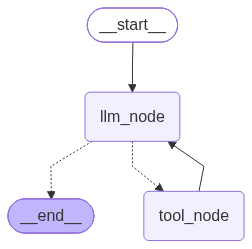

2026-08-14 15:50:05.313 | INFO     | __main__:tool_node:64 - 工具 get_weather 被调用, 对应的 tool_call: {'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'a7f1fd81-a23e-4e39-a3f6-9318781eede3', 'type': 'tool_call'}


============================== -> interrupt_res <- ==============================
================================ Human Message =================================

今天北京天气如何？
================================== Ai Message ==================================
Tool Calls:
  get_weather (a7f1fd81-a23e-4e39-a3f6-9318781eede3)
 Call ID: a7f1fd81-a23e-4e39-a3f6-9318781eede3
  Args:
    city: 北京
============================== -> interrupt_info <- ==============================
[Interrupt(value={'action': 'get_weather', 'question': '是否同意查询天气？'}, id='f94ed510db489cb708781917ebe940d4')]


2026-08-14 15:50:13.662 | INFO     | __main__:tool_node:64 - 工具 get_weather 被调用, 对应的 tool_call: {'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'a7f1fd81-a23e-4e39-a3f6-9318781eede3', 'type': 'tool_call'}
2026-08-14 15:50:13.663 | INFO     | __main__:get_weather:30 - is_approved: True


============================== -> approved_res <- ==============================
================================ Human Message =================================

今天北京天气如何？
================================== Ai Message ==================================
Tool Calls:
  get_weather (a7f1fd81-a23e-4e39-a3f6-9318781eede3)
 Call ID: a7f1fd81-a23e-4e39-a3f6-9318781eede3
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

北京 今天天气不错
================================== Ai Message ==================================

今天北京天气不错。
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	llm_node(llm_node)
	tool_node(tool_node)
	__end__([<p>__end__</p>]):::last
	__start__ --> llm_node;
	llm_node -.-> __end__;
	llm_node -.-> tool_node;
	tool_node --> llm_node;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [ ]:
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.graph.message import MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage, ToolMessage
from langchain.tools import tool
from langchain_deepseek import ChatDeepSeek
from rich import print as rprint
from langchain.chat_models import init_chat_model
import os

from loguru import logger
from dotenv import load_dotenv
load_dotenv(override=True)

@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    查询指定城市的当日天气

    Args:
        city: 城市名称
    """
    is_approved = interrupt({
        "action": "get_weather",
        "question": "是否同意查询天气？"
    })

    logger.info("is_approved: {}", is_approved)
    if is_approved:
        return f"{city} 今天天气不错"
    else:
        return "用户拒绝查询天气"

tools_by_name = {"get_weather": get_weather}

GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")
GEMINI_BASE_URL=os.getenv("GEMINI_BASE_URL")

model = init_chat_model(
  model="gemini-2.5-flash",
  model_provider="google_genai",
  api_key=GEMINI_API_KEY,
  transport="rest"  # 强制使用 REST 协议
)

model_with_tools = model.bind_tools([get_weather])

def llm_node(state: MessagesState) -> MessagesState:
    messages = state['messages']
    response = model_with_tools.invoke(messages)

    return {
        "messages": [response]
    }

def tool_node(state: MessagesState) -> MessagesState:
    last_msg = state['messages'][-1]

    tool_msgs = []
    for tool_call in last_msg.tool_calls:
        tool = tools_by_name[tool_call["name"]]
        logger.info("工具 {} 被调用, 对应的 tool_call: {}", tool_call["name"], tool_call)
        tool_res = tool.invoke(tool_call["args"])
        tool_msg = ToolMessage(
            name = tool_call["name"],
            content = tool_res,
            tool_call_id = tool_call["id"]
        )
        tool_msgs.append(tool_msg)

    return {
        "messages": tool_msgs
    }

def router(state: MessagesState) -> Literal["tool_node", END]:
    if state['messages'][-1].tool_calls:
        return "tool_node"
    return END

builder = StateGraph(state_schema=MessagesState)
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)
builder.add_edge(START, "llm_node")
builder.add_conditional_edges("llm_node", router, path_map=["tool_node", END])
builder.add_edge("tool_node", "llm_node")

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)

config = {"configurable": {"thread_id": "tool_test"}}
interrupted_res = graph.invoke({"messages": [HumanMessage("今天北京天气如何？")]}, config=config)
print('=' * 30, '-> interrupt_res <-', '=' * 30)
for msg in interrupted_res['messages']:
    msg.pretty_print()
print('=' * 30, '-> interrupt_info <-', '=' * 30)
print(interrupted_res['__interrupt__'])

user_approved = input("是否同意查询天气？(y/n): ").strip().lower() == 'y'
approved_res = graph.invoke(Command(resume=user_approved), config=config)
print('=' * 30, '-> approved_res <-', '=' * 30)
for msg in approved_res['messages']:
    msg.pretty_print()
    
